# Image compression with k-means (color quantization)

**Solution notebook.** An image is a grid of pixels, and every pixel is a point in **RGB space** --- three numbers. If we cluster the pixels with k-means and repaint each pixel with its cluster's centroid color, the image ends up using only **`k` colors**. That is *color quantization*: lossy compression you can actually see.

Seed is fixed to `509` throughout. Every figure and image produced here is written to the **`out/`** subfolder.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score

SEED = 509
np.random.seed(SEED)

OUT_DIR = "out"
os.makedirs(OUT_DIR, exist_ok=True)   # all results are written here

# Armenian flag colors, for plots with <= 3 series
ARM_RED, ARM_BLUE = "#D90012", "#0033A0"

## 1. Load the image

Original size (W x H): (605, 600)  |  pixels: 363,000


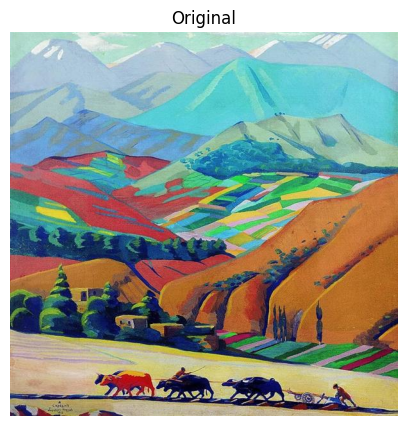

In [2]:
IMG_PATH = "img/saryan_mountains.jpg"

img = Image.open(IMG_PATH).convert("RGB")
print(f"Original size (W x H): {img.size}  |  pixels: {img.size[0] * img.size[1]:,}")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Original")
plt.axis("off")
plt.show()

## 2. Reshape to points and scale

k-means cost grows with the number of **pixels**, not the file size, so resize large images down first. Then flatten `(H, W, 3)` into `(n_pixels, 3)` and scale to `[0, 1]`.

In [3]:
MAX_WIDTH = 400  # resize for speed; the whole analysis below runs on this size
w, h = img.size
if w > MAX_WIDTH:
    img = img.resize((MAX_WIDTH, int(h * MAX_WIDTH / w)))
    print(f"Resized to (W x H): {img.size}  |  pixels: {img.size[0] * img.size[1]:,}")

arr = np.asarray(img)                                    # (H, W, 3), uint8 in [0, 255]
H, W, C = arr.shape
pixels = arr.reshape(-1, 3).astype(np.float64) / 255.0   # (n_pixels, 3) in [0, 1]

print(f"pixels shape: {pixels.shape}")
print(f"unique colors: {len(np.unique(pixels, axis=0)):,}")

Resized to (W x H): (400, 396)  |  pixels: 158,400
pixels shape: (158400, 3)


unique colors: 124,841


## 3. Quantize with k-means for several `k`

k= 2  inertia=13,863.3


k= 4  inertia=6,081.1


k= 8  inertia=3,196.6


k=16  inertia=1,802.6


k=32  inertia=1,008.9


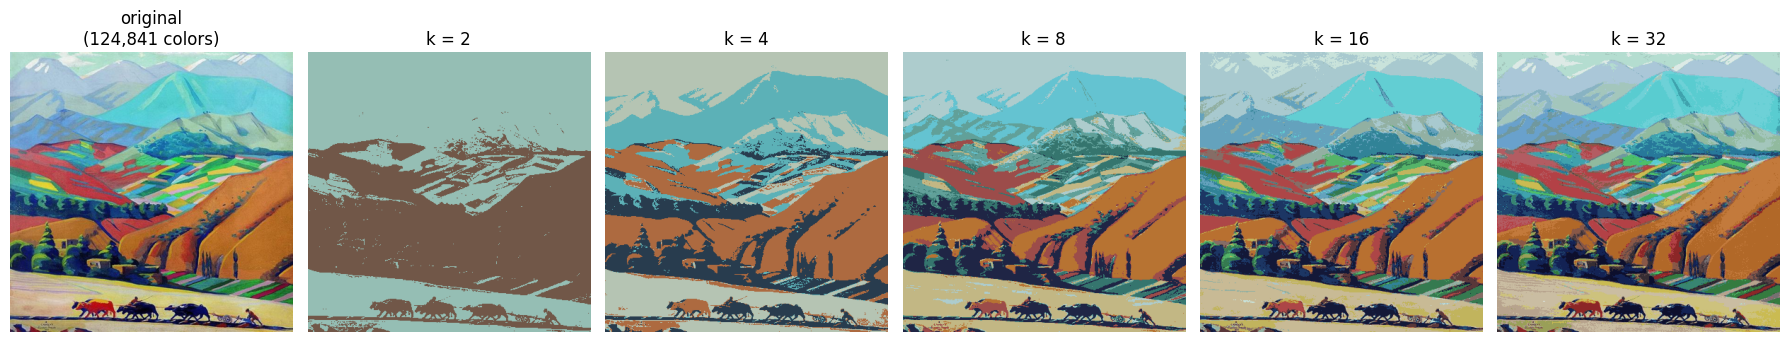

In [4]:
def quantize(pixels, k, shape, seed=SEED):
    # cluster pixels into k colors; return (quantized_image_uint8, fitted_kmeans)
    km = KMeans(n_clusters=k, n_init=10, random_state=seed)
    labels = km.fit_predict(pixels)
    quant = km.cluster_centers_[labels]                  # repaint each pixel with its centroid color
    quant_img = (quant.reshape(shape) * 255).round().astype(np.uint8)
    return quant_img, km


k_values = [2, 4, 8, 16, 32]
quant_images, kmeans_models = {}, {}

for k in k_values:
    quant_images[k], kmeans_models[k] = quantize(pixels, k, (H, W, C))
    Image.fromarray(quant_images[k]).save(os.path.join(OUT_DIR, f"saryan_k{k:02d}.jpg"), quality=95)
    print(f"k={k:>2}  inertia={kmeans_models[k].inertia_:,.1f}")

fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(3 * (len(k_values) + 1), 3.5))
axes[0].imshow(arr)
axes[0].set_title(f"original\n({len(np.unique(pixels, axis=0)):,} colors)")
axes[0].axis("off")
for ax, k in zip(axes[1:], k_values):
    ax.imshow(quant_images[k])
    ax.set_title(f"k = {k}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "comparison_grid.png"), dpi=120, bbox_inches="tight")
plt.show()

## 4. Pixels live in RGB space

Every pixel is a point with coordinates `(R, G, B)`. k-means groups these points and replaces each one with its group's center. Below: 3000 sampled pixels (faint, each drawn in its own color) and the **8 centroids** k-means chose (large markers). The entire image gets repainted with just those few colors. The plot is **interactive** --- drag to rotate, scroll to zoom.

In [5]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"   # compact mimebundle; Quarto supplies plotly.js

sample = pixels[np.random.choice(len(pixels), 3000, replace=False)]
cents = kmeans_models[8].cluster_centers_

def rgb_str(arr01):
    return [f"rgb({int(r*255)},{int(g*255)},{int(b*255)})" for r, g, b in arr01]

fig = go.Figure()
fig.add_scatter3d(
    x=sample[:, 0], y=sample[:, 1], z=sample[:, 2], mode="markers",
    marker=dict(size=2.5, color=rgb_str(sample), opacity=0.55), name="pixels",
)
fig.add_scatter3d(
    x=cents[:, 0], y=cents[:, 1], z=cents[:, 2], mode="markers",
    marker=dict(size=10, color=rgb_str(cents), line=dict(color="black", width=2)),
    name="centroids (k=8)",
)
fig.update_layout(
    title="Pixels in RGB space + k=8 centroids (drag to rotate, scroll to zoom)",
    scene=dict(xaxis_title="R", yaxis_title="G", zaxis_title="B"),
    width=720, height=620, margin=dict(l=0, r=0, t=40, b=0),
)
fig.write_html(os.path.join(OUT_DIR, "rgb_scatter.html"), include_plotlyjs="cdn")   # interactive artifact saved to out/
fig.show()

## 5. Choosing `k`

Two standard tools: the **elbow** (inertia keeps dropping --- look for the bend) and the **silhouette** (higher is better). The silhouette is expensive, so we sample pixels and reuse the models we already fit.

> **Honest caveat for this task.** Pixel colors form a *continuum*, not tidy separated clusters, so the silhouette here just **declines** as `k` grows --- it would pick `k = 2`, which is useless for quantization. For this task `k` is a **quality-vs-size trade-off**, not a "true number of clusters" --- pick the smallest `k` whose result still looks good.

k= 2  silhouette=0.458
k= 4  silhouette=0.455
k= 8  silhouette=0.408
k=16  silhouette=0.385
k=32  silhouette=0.351


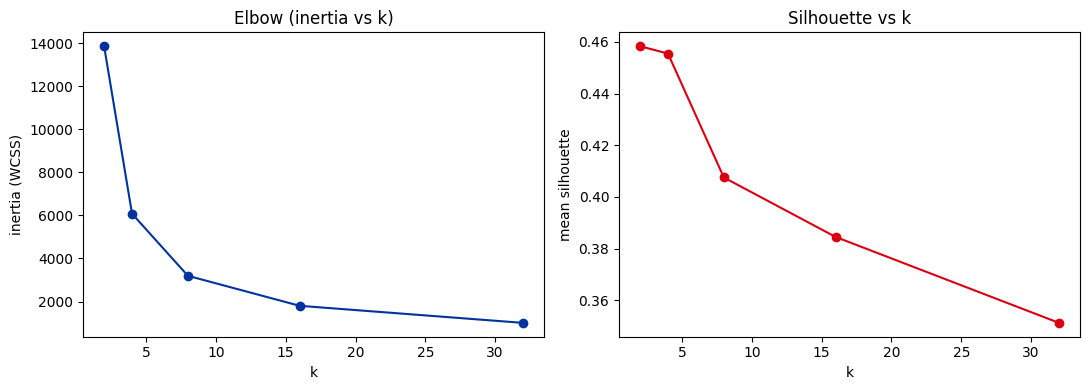

In [6]:
inertias = [kmeans_models[k].inertia_ for k in k_values]
sil_scores = [
    silhouette_score(pixels, kmeans_models[k].labels_, sample_size=3000, random_state=SEED)
    for k in k_values
]
for k, sil in zip(k_values, sil_scores):
    print(f"k={k:>2}  silhouette={sil:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(k_values, inertias, marker="o", color=ARM_BLUE)
ax[0].set(title="Elbow (inertia vs k)", xlabel="k", ylabel="inertia (WCSS)")
ax[1].plot(k_values, sil_scores, marker="o", color=ARM_RED)
ax[1].set(title="Silhouette vs k", xlabel="k", ylabel="mean silhouette")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "elbow_silhouette.png"), dpi=120)
plt.show()

## 6. The palette --- the `k` centroid colors

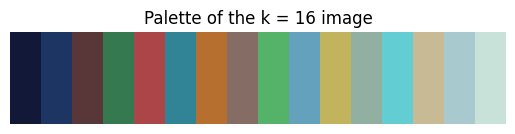

In [7]:
def show_palette(km, title, fname):
    colors = km.cluster_centers_                         # (k, 3) in [0, 1]
    order = np.argsort(colors.sum(axis=1))               # sort dark -> light so the strip reads nicely
    strip = colors[order][np.newaxis, :, :]              # (1, k, 3)
    plt.figure(figsize=(len(colors) * 0.4, 1.2))
    plt.imshow(strip, aspect="auto")
    plt.title(title)
    plt.axis("off")
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=120, bbox_inches="tight")
    plt.show()

show_palette(kmeans_models[16], "Palette of the k = 16 image", "palette_k16.png")

## 7. How much did we compress? (theory)

Measure the information, not a re-saved file.

- **Original:** 3 channels x 8 bits = **24 bits/pixel**.
- **Quantized:** one index per pixel = **`ceil(log2 k)` bits/pixel**, plus a tiny palette of `k x 3` bytes.

So the ratio is roughly `24 / ceil(log2 k)` for a large image. We also report the **reconstruction MSE** --- how far the repainted pixels sit from the originals.

In [8]:
def compression_report(pixels, km, k):
    n = pixels.shape[0]
    index_bits = int(np.ceil(np.log2(k)))                # bits to name one of k colors
    quantized_bits = n * index_bits + k * 3 * 8          # per-pixel indices + the palette
    original_bits = n * 3 * 8                             # 24 bits per pixel
    ratio = original_bits / quantized_bits

    quant = km.cluster_centers_[km.labels_]
    mse = np.mean((pixels - quant) ** 2)                 # in [0, 1] color space

    print(f"k = {k:>2} | {index_bits} bits/px (vs 24) | "
          f"{original_bits/8/1024:6.0f} KB -> {quantized_bits/8/1024:6.0f} KB | "
          f"{ratio:5.1f}x | MSE={mse:.5f} (RMSE ~ {np.sqrt(mse)*255:.1f}/255)")

for k in k_values:
    compression_report(pixels, kmeans_models[k], k)

k =  2 | 1 bits/px (vs 24) |    464 KB ->     19 KB |  24.0x | MSE=0.02917 (RMSE ~ 43.6/255)
k =  4 | 2 bits/px (vs 24) |    464 KB ->     39 KB |  12.0x | MSE=0.01280 (RMSE ~ 28.8/255)
k =  8 | 3 bits/px (vs 24) |    464 KB ->     58 KB |   8.0x | MSE=0.00673 (RMSE ~ 20.9/255)
k = 16 | 4 bits/px (vs 24) |    464 KB ->     77 KB |   6.0x | MSE=0.00379 (RMSE ~ 15.7/255)
k = 32 | 5 bits/px (vs 24) |    464 KB ->     97 KB |   4.8x | MSE=0.00212 (RMSE ~ 11.7/255)


## 8. Real file sizes: indexed PNG

The bits above are theoretical. Here is the real payoff: save each quantized image as an **indexed (palette) PNG** --- a format that stores one small palette plus one index per pixel, exactly the scheme we counted. The file genuinely shrinks as `k` drops.

(Re-saving as `.jpg` would *not* show this cleanly: JPEG runs its own lossy DCT compression, so its size reflects JPEG, not your color count.)

In [9]:
orig_png = os.path.join(OUT_DIR, "original.png")
Image.fromarray(arr).save(orig_png, optimize=True)
orig_size = os.path.getsize(orig_png)
print(f"original as lossless PNG: {orig_size/1024:6.1f} KB\n")

for k in k_values:
    path = os.path.join(OUT_DIR, f"indexed_k{k:02d}.png")
    # build the indexed PNG straight from the k-means result: one palette + one index per pixel
    palette = (kmeans_models[k].cluster_centers_ * 255).round().astype(np.uint8)   # (k, 3) colors
    index_img = kmeans_models[k].labels_.reshape(H, W).astype(np.uint8)            # one index per pixel
    im = Image.frombytes("P", (W, H), index_img.tobytes())
    im.putpalette(list(palette.flatten()))
    im.save(path, optimize=True)
    sz = os.path.getsize(path)
    print(f"k={k:>2}  indexed PNG: {sz/1024:6.1f} KB  ({orig_size/sz:5.1f}x smaller than original PNG)")

original as lossless PNG:  284.0 KB

k= 2  indexed PNG:    3.7 KB  ( 76.0x smaller than original PNG)
k= 4  indexed PNG:    8.9 KB  ( 32.0x smaller than original PNG)
k= 8  indexed PNG:   14.4 KB  ( 19.7x smaller than original PNG)
k=16  indexed PNG:   20.6 KB  ( 13.8x smaller than original PNG)
k=32  indexed PNG:   28.8 KB  (  9.8x smaller than original PNG)


## 9. Where it breaks

At small `k`, smooth gradients (sky, shadows) collapse into a few flat regions --- **banding / posterization**. That is the visible cost of too few colors.

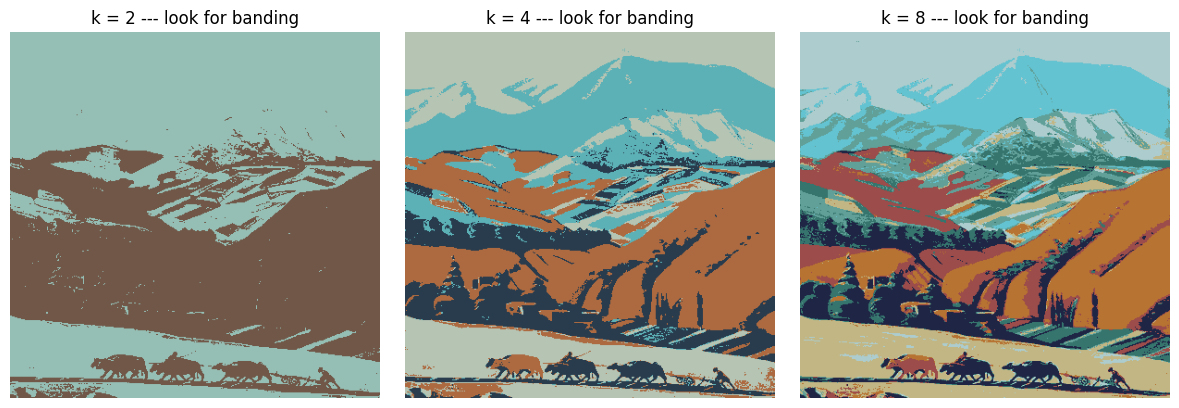

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, k in zip(axes, [2, 4, 8]):
    ax.imshow(quant_images[k])
    ax.set_title(f"k = {k} --- look for banding")
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "banding.png"), dpi=120, bbox_inches="tight")
plt.show()

## 10. Bonus --- `MiniBatchKMeans` on the full-resolution image

`MiniBatchKMeans` updates centroids from small random batches, so it quantizes the full image far faster than plain k-means, for a tiny quality cost.

full-res pixels: 363,000


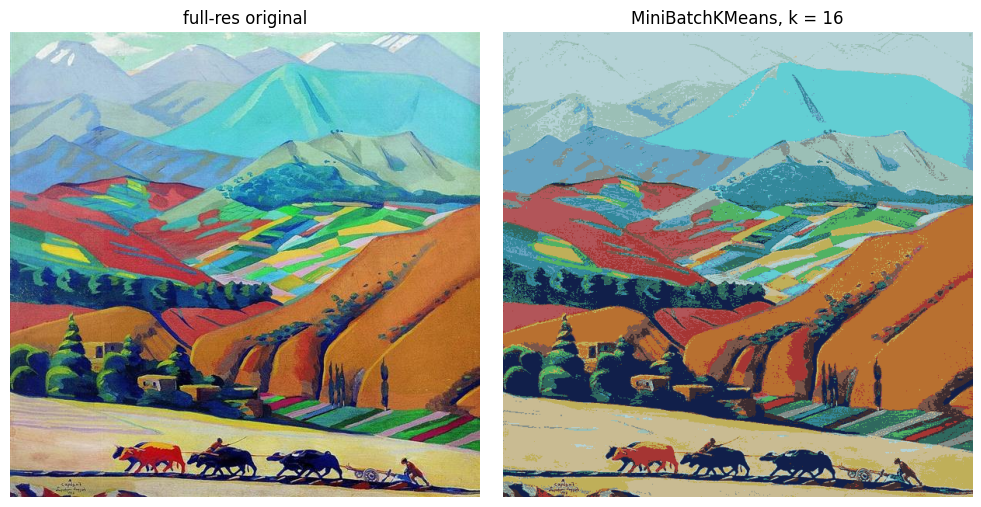

In [11]:
full = np.asarray(Image.open(IMG_PATH).convert("RGB"))
full_pixels = full.reshape(-1, 3).astype(np.float64) / 255.0
print(f"full-res pixels: {full_pixels.shape[0]:,}")

mbk = MiniBatchKMeans(n_clusters=16, random_state=SEED, n_init=3, batch_size=2048)
labels = mbk.fit_predict(full_pixels)
full_quant = (mbk.cluster_centers_[labels].reshape(full.shape) * 255).round().astype(np.uint8)
Image.fromarray(full_quant).save(os.path.join(OUT_DIR, "fullres_minibatch_k16.jpg"), quality=95)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(full);       ax[0].set_title("full-res original"); ax[0].axis("off")
ax[1].imshow(full_quant); ax[1].set_title("MiniBatchKMeans, k = 16"); ax[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fullres_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()

In [12]:
print("Files written to out/:")
for f in sorted(os.listdir(OUT_DIR)):
    print("  ", f, f"({os.path.getsize(os.path.join(OUT_DIR, f))/1024:,.0f} KB)")

Files written to out/:
   banding.png (279 KB)
   comparison_grid.png (763 KB)
   elbow_silhouette.png (45 KB)
   fullres_comparison.png (960 KB)
   fullres_minibatch_k16.jpg (168 KB)
   indexed_k02.png (4 KB)
   indexed_k04.png (9 KB)
   indexed_k08.png (14 KB)
   indexed_k16.png (21 KB)
   indexed_k32.png (29 KB)
   original.png (284 KB)
   palette_k16.png (4 KB)
   rgb_scatter.html (175 KB)
   saryan_k02.jpg (42 KB)
   saryan_k04.jpg (72 KB)
   saryan_k08.jpg (78 KB)
   saryan_k16.jpg (82 KB)
   saryan_k32.jpg (87 KB)


## Conclusion

- Treating pixels as points in RGB space turns compression into a **clustering** problem: k-means finds `k` representative colors (see the 3D scatter) and we repaint the image with them.
- Inertia falls smoothly with `k`, while the silhouette only **declines** (it would pick `k = 2`) --- so for quantization `k` is a **quality/size trade-off**, not a natural cluster count. Around `k = 16-32` the result looks close to the original.
- The payoff is real, not just theory: saved as **indexed PNGs** the files shrink steeply as `k` drops --- in fact *more* than the `~24 / ceil(log2 k)` raw-index estimate, because PNG also losslessly compresses (DEFLATE) the index stream; reconstruction MSE shrinks as `k` grows.
- At very small `k` the cost is visible as **banding** in smooth regions.
- All figures and images are saved under **`out/`**.